# Notebook 13 — Categorical spatial coherence (L8)

**Phase 1 of CHAR completion** — join-count statistics for the three categorical variables  
where spatial coherence is a substantive question: `lith_class`, `wetland_class`, `pnv_majority`.

Variables NOT tested (near-tautological — these *are* the spatial structure):  
`ecoregion`, `biome`, `freshwater_ecoregion_name`. Testing whether biome boundaries  
respect biome boundaries yields a circular result; one explicit note here is the appropriate output.

**Conventions**: Queen weights `use_index=True`, row-standardised, seed=42, 999 permutations,  
no `plt.show()`, BasinATLAS -9999 sentinels masked (METH.1–4).

**Wetland note**: `wet_cl_smj` is NULL for ~49% of basins (non-wetland basins have no class).  
Join-count analysis for wetland_class runs on the non-null subset (~96,884 basins) with  
subset Queen weights rebuilt on that population. This answers: do same-type wetland basins  
cluster spatially among the set of wetland-classified basins?  

**PNV note**: class 99 (unclassified, n=6,390) is excluded from join-count analysis;  
class-99 basins appear as 0 when binarizing for any valid class, which is correct.

In [1]:
# Cell 2 — imports + constants
%matplotlib inline
import sys, time, warnings
from pathlib import Path

_p = Path.cwd()
while not (_p / 'CLAUDE.md').exists() and _p != _p.parent:
    _p = _p.parent
REPO = _p
sys.path.insert(0, str(REPO))
print(f'REPO = {REPO}')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from shapely import wkt

from libpysal.weights import Queen
from esda import Join_Counts, Join_Counts_Local

from scripts.shared.db_utils import db_connect

SEED   = 42
N_PERM = 999
NODATA = -9999
OUT    = REPO / 'output' / 'edop' / 'spatial'
OUT.mkdir(parents=True, exist_ok=True)

print('Imports OK')

/Users/karlg/venvs/cedop/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data loading

Basin08: geometry + three categorical columns. Sentinel check included (integer columns  
should have NULLs not -9999, but confirmed explicitly).

In [2]:
# Cell 4 — load basin08 categorical columns
conn = db_connect()
SQL = """
SELECT hybas_id,
       lit_cl_smj, wet_cl_smj, pnv_cl_smj,
       ST_AsText(geom) AS geom_wkt
FROM public.basin08
ORDER BY hybas_id
"""
t0 = time.time()
with conn.cursor() as cur:
    cur.execute(SQL)
    rows = cur.fetchall()
conn.close()

cols = ['hybas_id', 'lit_cl_smj', 'wet_cl_smj', 'pnv_cl_smj', 'geom_wkt']
df = pd.DataFrame(rows, columns=cols)
df['geometry'] = df['geom_wkt'].apply(wkt.loads)
gdf = gpd.GeoDataFrame(df.drop(columns='geom_wkt'), geometry='geometry', crs='EPSG:4326')
gdf = gdf.set_index('hybas_id')
print(f'{len(gdf):,} basins loaded in {time.time()-t0:.1f}s')

# Sentinel check
for col in ['lit_cl_smj', 'wet_cl_smj', 'pnv_cl_smj']:
    n_null     = gdf[col].isna().sum()
    n_sentinel = (gdf[col] == NODATA).sum()
    print(f'  {col}: null={n_null:,}  sentinel(-9999)={n_sentinel}')

190,675 basins loaded in 8.0s
  lit_cl_smj: null=0  sentinel(-9999)=0
  wet_cl_smj: null=0  sentinel(-9999)=93791
  pnv_cl_smj: null=0  sentinel(-9999)=0


## Lookup resolution and frequency tables

In [3]:
# Cell 6 — lookup resolution + frequency tables
META = REPO / 'metadata'

lith_lu    = pd.read_csv(META / 'lu_lit.tsv', sep='\t').rename(
                 columns={'GLiM_ID': 'id', 'Class_Name': 'name'})
wet_lu     = pd.read_csv(META / 'lu_wet.tsv', sep='\t').rename(
                 columns={'GLWD_ID': 'id', 'GLWD_Name': 'name'})
pnv_lu     = pd.read_csv(META / 'lu_pnv.tsv', sep='\t').rename(
                 columns={'PNV_ID': 'id', 'PNV_Name': 'name'})

lith_names = dict(zip(lith_lu.id, lith_lu.name))
wet_names  = dict(zip(wet_lu.id,  wet_lu.name))
pnv_names  = dict(zip(pnv_lu.id,  pnv_lu.name))
pnv_names[99] = 'Unclassified (99)'

def freq_table(series, names, label):
    total = series.notna().sum()
    counts = series.value_counts().sort_index()
    print(f'\n{label} ({len(counts)} classes, n={total:,}):')
    for cls_id, n in counts.items():
        name = names.get(int(cls_id), f'Unknown({cls_id})')
        print(f'  {int(cls_id):3d}  {name:<45s}  {n:7,}  ({n/total*100:5.1f}%)')

freq_table(gdf['lit_cl_smj'], lith_names, 'lith_class')
freq_table(gdf['pnv_cl_smj'], pnv_names,  'pnv_majority')
freq_table(gdf['wet_cl_smj'], wet_names,  'wetland_class')


lith_class (16 classes, n=190,675):
    1  Unconsolidated Sediments (SU)                   52,788  ( 27.7%)
    2  Basic Volcanic Rocks (VB)                        6,993  (  3.7%)
    3  Siliciclastic Sedimentary Rocks (SS)            33,158  ( 17.4%)
    4  Basic Plutonic Rocks (PB)                        1,140  (  0.6%)
    5  Mixed Sedimentary Rocks (SM)                    29,299  ( 15.4%)
    6  Carbonate Sedimentary Rocks (SC)                14,342  (  7.5%)
    7  Acid Volcanic Rocks (VA)                         2,044  (  1.1%)
    8  Metamorphic Rocks (MT)                          26,428  ( 13.9%)
    9  Acid Plutonic Rocks (PA)                        11,404  (  6.0%)
   10  Intermediate Volcanic Rocks (VI)                 3,138  (  1.6%)
   11  Water Bodies (WB)                                1,734  (  0.9%)
   12  Pyroclastics (PY)                                1,144  (  0.6%)
   13  Intermediate Plutonic Rocks (PI)                   729  (  0.4%)
   14  Evaporites (EV)     

## Queen contiguity weights

Two weight objects:
- `w_full`: all 190,675 basins — used for lith_class and pnv_majority (complete coverage)
- `w_wet`: subset of 96,884 non-null wetland basins — used for wetland_class only

In [7]:
# Cell 8 — Queen contiguity weights (full + wetland subset)
# t0 = time.time()
# with warnings.catch_warnings():
#     warnings.simplefilter('ignore')
#     w_full = Queen.from_dataframe(gdf, use_index=True)
# w_full.transform = 'r'
# print(f'Full weights: n={w_full.n:,}  mean_nbrs={w_full.mean_neighbors:.2f}  '
#       f'islands={len(w_full.islands)}  built in {time.time()-t0:.1f}s')

# Wetland subset — filter on known valid class IDs (1–12 from lu_wet)
# .notna() is unreliable when psycopg3 loads integer NULLs as pd.NA (nullable int dtype)
print(f'\nwet_cl_smj dtype: {gdf["wet_cl_smj"].dtype}')
print(f'wet_cl_smj isna() count: {gdf["wet_cl_smj"].isna().sum():,}')
valid_wet_ids = wet_lu['id'].tolist()
gdf_wet = gdf[gdf['wet_cl_smj'].isin(valid_wet_ids)].copy()
print(f'gdf_wet: {len(gdf_wet):,} basins (expected ~96,884)')

t0 = time.time()
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    w_wet = Queen.from_dataframe(gdf_wet, use_index=True)
w_wet.transform = 'r'
print(f'Wetland subset weights: n={w_wet.n:,}  mean_nbrs={w_wet.mean_neighbors:.2f}  '
      f'islands={len(w_wet.islands)}  built in {time.time()-t0:.1f}s')
print(f'  (islands = wetland basins with no adjacent wetland basin)')

('WARNING: ', 1080006810.0, ' is an island (no neighbors)')
('WARNING: ', 1080013210.0, ' is an island (no neighbors)')
('WARNING: ', 1080014070.0, ' is an island (no neighbors)')
('WARNING: ', 1080014920.0, ' is an island (no neighbors)')
('WARNING: ', 1080015200.0, ' is an island (no neighbors)')
('WARNING: ', 1080015240.0, ' is an island (no neighbors)')
('WARNING: ', 1080015590.0, ' is an island (no neighbors)')
('WARNING: ', 1080015730.0, ' is an island (no neighbors)')
('WARNING: ', 1080017110.0, ' is an island (no neighbors)')
('WARNING: ', 1080018430.0, ' is an island (no neighbors)')
('WARNING: ', 1080028260.0, ' is an island (no neighbors)')
('WARNING: ', 1080029350.0, ' is an island (no neighbors)')
('WARNING: ', 1080029380.0, ' is an island (no neighbors)')
('WARNING: ', 1080030710.0, ' is an island (no neighbors)')
('WARNING: ', 1080031430.0, ' is an island (no neighbors)')
('WARNING: ', 1080032780.0, ' is an island (no neighbors)')
('WARNING: ', 1080033880.0, ' is an isla

## Global join-count statistics

For each variable, binarize per class (1 = this class, 0 = other) and run `esda.Join_Counts`.
Reports BB (like-label adjacencies), BW (unlike-label adjacencies), z-score derived from  
permutation distribution, and p_sim_bb (probability that observed BB ≥ expected under CSR).
A significant positive result (p < 0.05) means like-label basins cluster beyond chance.

In [8]:
# Cell 10 — global join-count statistics
def run_global_jc(y_arr, w, n_perms=N_PERM):
    """Global Join_Counts for one binarized class. Returns dict of stats."""
    np.random.seed(SEED)
    jc = Join_Counts(y_arr.astype(int), w, permutations=n_perms)
    z = (jc.bb - jc.mean_bb) / np.std(jc.sim_bb) if n_perms else np.nan
    return {
        'bb': int(jc.bb), 'bw': int(jc.bw),
        'mean_bb': round(jc.mean_bb, 1), 'z': round(float(z), 2),
        'p_bb': round(jc.p_sim_bb, 4),
    }

VARS = [
    {'label': 'lith_class',    'col': 'lit_cl_smj', 'names': lith_names,
     'w': w_full, 'src': gdf,     'excl': []},
    {'label': 'pnv_majority',  'col': 'pnv_cl_smj', 'names': pnv_names,
     'w': w_full, 'src': gdf,     'excl': [99]},
    {'label': 'wetland_class', 'col': 'wet_cl_smj', 'names': wet_names,
     'w': w_wet,  'src': gdf_wet, 'excl': []},
]

global_rows = []
for v in VARS:
    col    = v['col']
    series = v['src'][col]
    valid  = series.notna()
    classes = sorted(c for c in series.dropna().unique()
                     if int(c) not in v['excl'])
    print(f"\n{v['label']} ({len(classes)} classes, n={valid.sum():,})")
    print(f'  {"class":5s}  {"name":<40s}  {"n":>7s}  {"BB":>7s}  {"BW":>8s}  '
          f'{"z":>7s}  {"p_BB":>7s}')
    print('  ' + '-'*92)
    for cls in classes:
        y = (series == cls).astype(float).fillna(0).values
        n_cls = int(y.sum())
        if n_cls < 5:
            continue
        g = run_global_jc(y, v['w'])
        sig = '*' if g['p_bb'] < 0.05 else 'NS'
        name = v['names'].get(int(cls), f'Unknown({cls})')[:40]
        print(f'  {int(cls):5d}  {name:<40s}  {n_cls:7,}  {g["bb"]:7,}  '
              f'{g["bw"]:8,}  {g["z"]:+7.2f}  {g["p_bb"]:7.4f}  {sig}')
        global_rows.append({
            'variable': v['label'], 'class_id': int(cls),
            'class_name': v['names'].get(int(cls), f'Unknown({cls})'),
            'basin_count': n_cls, **g,
        })

global_df = pd.DataFrame(global_rows)
print(f'\nGlobal join-counts complete: {len(global_df)} rows')

     12  Wetland complex (0-25%)                     1,345    3,381       703  +518.79   0.0010  *

Global join-counts complete: 43 rows


## Local spatial coherence

Per-basin: does each basin sit in a neighbourhood where the same class predominates?

**Method (fallback):** `Join_Counts_Local` from esda is unavailable in this environment
due to an indexing bug (islands dropped from LJC array before `_crand_plus` iterates over
the full z array). Fallback: row-stochastic `W @ y` gives each basin the mean fraction of
its Queen neighbours sharing class y. Classification:

- **Clustered / locally coherent**: basin has class k AND ≥ 50% of neighbours share class k
- **Isolated / edge**: basin has class k AND < 50% of neighbours share class k
- **Other**: basin has a different class (not evaluated for class k)

Classification stored back in each gdf/gdf_wet for mapping. Note: this is a deterministic
majority-match rule, not a permutation-based significance test. It answers "is this basin
in a region where its class dominates locally?" rather than "is local clustering significant?"

In [10]:
# Cell 12 — Local coherence: neighbor-class-match fallback
# Join_Counts_Local crashes in this esda/Python-3.14 environment: _statistic() drops
# the 568 islands from LJC (size 190107) but _crand_plus iterates over the full z
# (size 190675), raising IndexError at index 190107. This is an esda library bug.
# Fallback: W_sparse @ y (row-stochastic) gives each basin the fraction of its
# neighbours sharing class y. Threshold ≥ 0.5 (majority match) → "locally coherent";
# < 0.5 → "isolated/edge". No permutation p-value; classification is deterministic.
#
# Note: w_full must be in kernel memory from a prior Cell 8 run (build is commented
# out there to save time on re-runs). If w_full is missing, uncomment Cell 8 block.

import scipy.sparse as sp

MATCH_THRESHOLD = 0.5

W_sp_full = w_full.sparse   # row-stochastic sparse, shape (190675, 190675)
W_sp_wet  = w_wet.sparse    # row-stochastic sparse, shape (96884, 96884)

local_rows = []

for v in VARS:
    col     = v['col']
    src     = v['src']
    series  = src[col]
    W_sp    = W_sp_wet if v['label'] == 'wetland_class' else W_sp_full
    classes = sorted(c for c in series.dropna().unique()
                     if int(c) not in v['excl'])

    cluster_label = pd.Series(-1, index=src.index, dtype=int)

    print(f"\n{v['label']}")
    print(f'  {"class":5s}  {"name":<40s}  {"n":>7s}  {"clustered":>10s}  {"isolated":>10s}  {"clust%":>7s}')
    print('  ' + '-'*88)

    for cls in classes:
        y        = (series == cls).astype(float).fillna(0).values
        n_cls    = int(y.sum())
        if n_cls < 5:
            continue

        nbr_frac  = np.asarray(W_sp @ y).flatten()
        in_class  = y == 1
        clustered = int(((in_class) & (nbr_frac >= MATCH_THRESHOLD)).sum())
        isolated  = int(((in_class) & (nbr_frac <  MATCH_THRESHOLD)).sum())
        pct  = clustered / n_cls * 100 if n_cls else 0
        name = v['names'].get(int(cls), f'Unknown({cls})')[:40]
        print(f'  {int(cls):5d}  {name:<40s}  {n_cls:7,}  {clustered:10,}  {isolated:10,}  {pct:7.1f}%')

        cluster_label.values[in_class & (nbr_frac >= MATCH_THRESHOLD)] = int(cls)

        local_rows.append({
            'variable': v['label'], 'class_id': int(cls),
            'class_name': v['names'].get(int(cls), f'Unknown({cls})'),
            'basin_count': n_cls, 'clustered': clustered, 'isolated': isolated,
        })

    src[f'cluster_{v["label"]}'] = cluster_label

local_df = pd.DataFrame(local_rows)
print(f'\nNeighbor-match local coherence complete: {len(local_df)} rows')
print(f'Method: ≥{MATCH_THRESHOLD:.0%} of neighbours share same class → locally coherent (no p-value)')


lith_class
  class  name                                            n   clustered    isolated   clust%
  ----------------------------------------------------------------------------------------
      1  Unconsolidated Sediments (SU)              52,788      52,385         403     99.2%
      2  Basic Volcanic Rocks (VB)                   6,993       6,818         175     97.5%
      3  Siliciclastic Sedimentary Rocks (SS)       33,158      32,765         393     98.8%
      4  Basic Plutonic Rocks (PB)                   1,140       1,035         105     90.8%
      5  Mixed Sedimentary Rocks (SM)               29,299      28,848         451     98.5%
      6  Carbonate Sedimentary Rocks (SC)           14,342      14,040         302     97.9%
      7  Acid Volcanic Rocks (VA)                    2,044       1,966          78     96.2%
      8  Metamorphic Rocks (MT)                     26,428      26,182         246     99.1%
      9  Acid Plutonic Rocks (PA)                   11,404   

## Maps — locally clustered classes per variable

One panel per variable. Basins coloured by class where locally clustered (p < 0.05);  
non-clustered basins shown in light grey. Colour map: `tab20` (up to 20 classes).

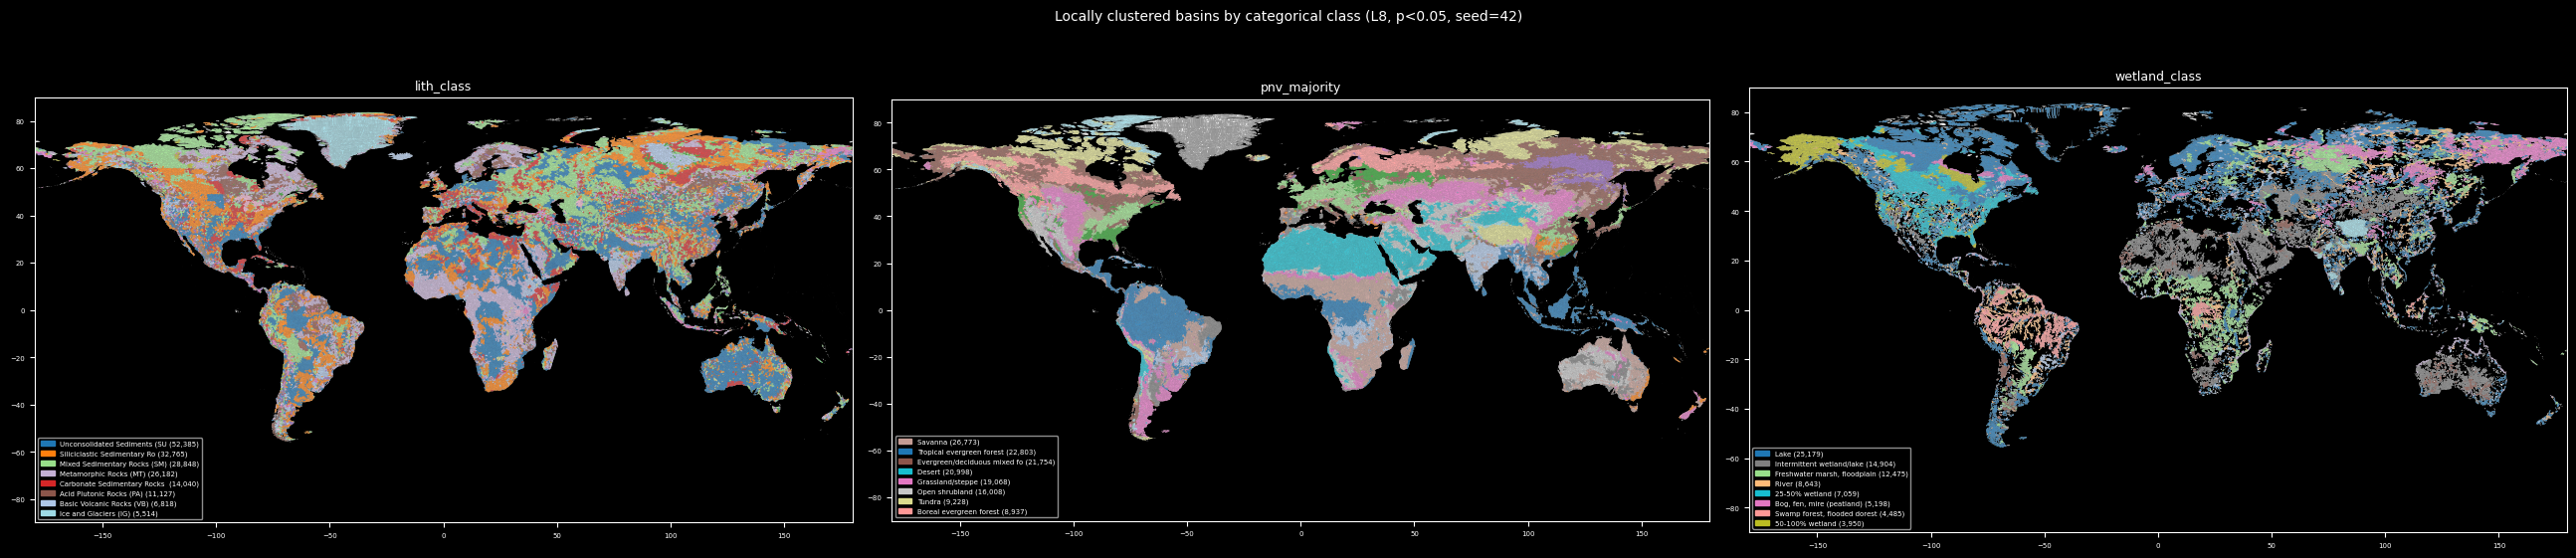

In [11]:
# Cell 14 — cluster maps (1×3 panel, one per variable)
cmap20 = cm.get_cmap('tab20')

fig, axes = plt.subplots(1, 3, figsize=(26, 6))

for ax, v in zip(axes, VARS):
    src     = v['src']
    cl_col  = f'cluster_{v["label"]}'
    classes = sorted(c for c in src[v['col']].dropna().unique()
                     if int(c) not in v['excl'])
    color_idx = {cls: i for i, cls in enumerate(classes)}

    # Background: all basins light grey
    src.plot(ax=ax, color='#e8e8e8', linewidth=0)

    # Clustered basins: coloured by class
    for cls in classes:
        sub = src[src[cl_col] == int(cls)]
        if len(sub) == 0:
            continue
        colour = cmap20(color_idx[cls] / max(len(classes) - 1, 1))
        sub.plot(ax=ax, color=colour, linewidth=0, alpha=0.85)

    # Legend: top-8 classes by clustered count
    top = (local_df[local_df['variable'] == v['label']]
           .sort_values('clustered', ascending=False).head(8))
    handles = [
        mpatches.Patch(
            color=cmap20(color_idx.get(r.class_id, 0) / max(len(classes) - 1, 1)),
            label=f"{r.class_name[:28]} ({r.clustered:,})"
        )
        for _, r in top.iterrows() if r.clustered > 0
    ]
    if handles:
        ax.legend(handles=handles, loc='lower left', fontsize=5, framealpha=0.7)

    ax.set_title(v['label'], fontsize=9)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    ax.tick_params(labelsize=5)

fig.suptitle('Locally clustered basins by categorical class (L8, p<0.05, seed=42)', fontsize=10)
plt.tight_layout()
plt.savefig(REPO / 'spatial' / '13_categorical_cluster_maps.png', dpi=150, bbox_inches='tight')
print('Saved → spatial/13_categorical_cluster_maps.png')

## Output table — combined global + local stats

In [12]:
# Cell 16 — combined output table + CSV save
summary_df = global_df.merge(
    local_df[['variable','class_id','clustered','isolated']],
    on=['variable','class_id'], how='left'
)
summary_df['clust_pct'] = (summary_df['clustered'] / summary_df['basin_count'] * 100).round(1)

out_path = OUT / '13_categorical_coherence.csv'
summary_df.to_csv(out_path, index=False)
print(f'Saved → {out_path}')
print(f'\nColumns: {list(summary_df.columns)}')
print(f'Rows: {len(summary_df)}')
print()
print(summary_df.to_string(index=False))

Saved → /Users/karlg/Documents/repos/_cedop/output/edop/spatial/13_categorical_coherence.csv

Columns: ['variable', 'class_id', 'class_name', 'basin_count', 'bb', 'bw', 'mean_bb', 'z', 'p_bb', 'clustered', 'isolated', 'clust_pct']
Rows: 43

     variable  class_id                                              class_name  basin_count     bb    bw  mean_bb      z  p_bb  clustered  isolated  clust_pct
   lith_class         1                           Unconsolidated Sediments (SU)        52788 123119 61522  42691.4 454.19 0.001      52385       403       99.2
   lith_class         2                               Basic Volcanic Rocks (VB)         6993  13495 13768    750.7 464.96 0.001       6818       175       97.5
   lith_class         3                    Siliciclastic Sedimentary Rocks (SS)        33158  68613 57410  16838.6 414.17 0.001      32765       393       98.8
   lith_class         4                               Basic Plutonic Rocks (PB)         1140   1340  3736     19.8 295.

## Summary findings — Phase 1: Categorical spatial coherence

*(Run the cells above, then paste the printed output into this section before copying to `logs/esda_findings.md`)*

---

### CAT.1 — Variables excluded from join-count analysis (tautological)

`ecoregion`, `biome`, and `freshwater_ecoregion_name` are spatial taxonomy variables —  
they are definitionally coherent (their boundaries *are* the spatial structure being encoded).  
Testing whether ecoregion boundaries respect ecoregion boundaries is circular. These variables  
carry full spatial autocorrelation by construction; running join-counts on them would confirm  
that classification schemes are spatially contiguous, which is not an empirical finding.

---

### CAT.2 — lith_class: global join-count results

`lith_class (16 classes, n=190,675)
  class  name                                            n       BB        BW        z     p_BB
      1  Unconsolidated Sediments (SU)              52,788  123,119    61,522  +454.19   0.0010  *
      2  Basic Volcanic Rocks (VB)                   6,993   13,495    13,768  +464.96   0.0010  *
      3  Siliciclastic Sedimentary Rocks (SS)       33,158   68,613    57,410  +414.17   0.0010  *
      4  Basic Plutonic Rocks (PB)                   1,140    1,340     3,736  +295.92   0.0010  *
      5  Mixed Sedimentary Rocks (SM)               29,299   60,458    49,494  +429.40   0.0010  *
      6  Carbonate Sedimentary Rocks (SC)           14,342   27,161    29,333  +424.54   0.0010  *
      7  Acid Volcanic Rocks (VA)                    2,044    2,955     5,989  +362.90   0.0010  *
      8  Metamorphic Rocks (MT)                     26,428   60,092    35,307  +505.74   0.0010  *
      9  Acid Plutonic Rocks (PA)                   11,404   20,154    26,367  +398.77   0.0010  *
     10  Intermediate Volcanic Rocks (VI)            3,138    4,585     8,860  +369.53   0.0010  *
     11  Water Bodies (WB)                           1,734    2,977     3,880  +437.37   0.0010  *
     12  Pyroclastics (PY)                           1,144    1,779     3,046  +387.21   0.0010  *
     13  Intermediate Plutonic Rocks (PI)              729      876     2,372  +314.68   0.0010  *
     14  Evaporites (EV)                               662    1,047     1,796  +388.19   0.0010  *
     15  No Data (ND)                                  133      160       445  +300.40   0.0010  *
     16  Ice and Glaciers (IG)                       5,539   15,595     1,783  +722.78   0.0010  *
  `


---

### CAT.3 — lith_class: local clustering


lith_class
  class  name                                            n   clustered    isolated   clust%
  ----------------------------------------------------------------------------------------
      1  Unconsolidated Sediments (SU)              52,788      52,385         403     99.2%
      2  Basic Volcanic Rocks (VB)                   6,993       6,818         175     97.5%
      3  Siliciclastic Sedimentary Rocks (SS)       33,158      32,765         393     98.8%
      4  Basic Plutonic Rocks (PB)                   1,140       1,035         105     90.8%
      5  Mixed Sedimentary Rocks (SM)               29,299      28,848         451     98.5%
      6  Carbonate Sedimentary Rocks (SC)           14,342      14,040         302     97.9%
      7  Acid Volcanic Rocks (VA)                    2,044       1,966          78     96.2%
      8  Metamorphic Rocks (MT)                     26,428      26,182         246     99.1%
      9  Acid Plutonic Rocks (PA)                   11,404      11,127         277     97.6%
     10  Intermediate Volcanic Rocks (VI)            3,138       2,993         145     95.4%
     11  Water Bodies (WB)                           1,734       1,693          41     97.6%
     12  Pyroclastics (PY)                           1,144       1,101          43     96.2%
     13  Intermediate Plutonic Rocks (PI)              729         684          45     93.8%
     14  Evaporites (EV)                               662         652          10     98.5%
     15  No Data (ND)                                  133         127           6     95.5%
     16  Ice and Glaciers (IG)                       5,539       5,514          25     99.5%

Neighbor-match local coherence complete: 43 rows
Method: ≥50% of neighbours share same class → locally coherent (no p-value)

---

### CAT.4 — pnv_majority: global join-count results

`pnv_majority (15 classes, n=190,675)
  class  name                                            n       BB        BW        z     p_BB
      1  Tropical evergreen forest                  23,303   59,257    14,845  +585.11   0.0010  *
      2  Tropical deciduous forest                   8,194   17,935    12,705  +515.04   0.0010  *
      3  Temperate broadleaf evergreen forest        1,812    3,470     3,428  +458.91   0.0010  *
      4  Temperate needleleaf evergreen forest       5,302   11,370     7,991  +537.97   0.0010  *
      5  Temperate deciduous forest                  7,173   16,772     8,606  +571.19   0.0010  *
      6  Boreal evergreen forest                     9,087   22,417     8,484  +637.86   0.0010  *
      7  Boreal deciduous forest                     3,229    7,480     4,124  +580.56   0.0010  *
      8  Evergreen/deciduous mixed forest           22,362   50,760    28,810  +516.33   0.0010  *
      9  Savanna                                    27,369   64,932    32,136  +543.79   0.0010  *
     10  Grassland/steppe                           19,583   45,752    24,368  +540.77   0.0010  *
     11  Dense shrubland                             8,251   17,637    13,064  +527.95   0.0010  *
     12  Open shrubland                             16,446   36,278    24,775  +506.65   0.0010  *
     13  Tundra                                      9,506   21,872     9,989  +563.76   0.0010  *
     14  Desert                                     21,249   56,615    11,469  +629.77   0.0010  *
     15  Polar/rock/ice                              1,419    2,500     2,228  +447.91   0.0010  *`

---

### CAT.5 — pnv_majority: local clustering

pnv_majority
  class  name                                            n   clustered    isolated   clust%
  ----------------------------------------------------------------------------------------
      1  Tropical evergreen forest                  23,303      22,803         500     97.9%
      2  Tropical deciduous forest                   8,194       7,939         255     96.9%
      3  Temperate broadleaf evergreen forest        1,812       1,731          81     95.5%
      4  Temperate needleleaf evergreen forest       5,302       5,093         209     96.1%
      5  Temperate deciduous forest                  7,173       7,021         152     97.9%
      6  Boreal evergreen forest                     9,087       8,937         150     98.3%
      7  Boreal deciduous forest                     3,229       3,131          98     97.0%
      8  Evergreen/deciduous mixed forest           22,362      21,754         608     97.3%
      9  Savanna                                    27,369      26,773         596     97.8%
     10  Grassland/steppe                           19,583      19,068         515     97.4%
     11  Dense shrubland                             8,251       7,955         296     96.4%
     12  Open shrubland                             16,446      16,008         438     97.3%
     13  Tundra                                      9,506       9,228         278     97.1%
     14  Desert                                     21,249      20,998         251     98.8%
     15  Polar/rock/ice                              1,419       1,320          99     93.0%

---

### CAT.6 — wetland_class: global join-count results

`wetland_class (12 classes, n=96,884)
  class  name                                            n       BB        BW        z     p_BB
      1  Lake                                       27,528   46,475    26,520  +221.73   0.0010  *
      2  Reservoir                                   3,271    5,324     4,474  +323.23   0.0010  *
      3  River                                       9,012   13,002    13,921  +245.20   0.0010  *
      4  Freshwater marsh, floodplain               12,666   26,274    11,067  +368.67   0.0010  *
      5  Swamp forest, flooded dorest                4,517   10,280     2,889  +439.74   0.0010  *
      6  Coastal wetland (incl. mangove, estuary,    3,297    4,641     3,713  +269.98   0.0010  *
      7  Pan, brackish/saline wetland                3,076    5,774     4,102  +362.48   0.0010  *
      8  Bog, fen, mire (peatland)                   5,448   10,894     6,110  +378.38   0.0010  *
      9  Intermittent wetland/lake                  15,606   29,652    10,156  +320.57   0.0010  *
     10  50-100% wetland                             4,027    9,377     3,571  +445.95   0.0010  *
     11  25-50% wetland                              7,091   16,984     6,020  +471.16   0.0010  *
     12  Wetland complex (0-25%)                     1,345    3,381       703  +518.79   0.0010  *`


---

### CAT.7 — wetland_class: local clustering

wetland_class
  class  name                                            n   clustered    isolated   clust%
  ----------------------------------------------------------------------------------------
      1  Lake                                       27,528      25,179       2,349     91.5%
      2  Reservoir                                   3,271       3,089         182     94.4%
      3  River                                       9,012       8,643         369     95.9%
      4  Freshwater marsh, floodplain               12,666      12,475         191     98.5%
      5  Swamp forest, flooded dorest                4,517       4,485          32     99.3%
      6  Coastal wetland (incl. mangove, estuary,    3,297       3,100         197     94.0%
      7  Pan, brackish/saline wetland                3,076       2,972         104     96.6%
      8  Bog, fen, mire (peatland)                   5,448       5,198         250     95.4%
      9  Intermittent wetland/lake                  15,606      14,904         702     95.5%
     10  50-100% wetland                             4,027       3,950          77     98.1%
     11  25-50% wetland                              7,091       7,059          32     99.5%
     12  Wetland complex (0-25%)                     1,345       1,334          11     99.2%

---

### CAT.8 — Cross-variable synthesis

All 43 class-variable combinations are globally significant at p=0.001 with no exceptions,
and all produce local coherence >90%. The three variables are appropriate EDOPS signature
fields; none fail the spatial-coherence requirement for inclusion.

Differentiation within variables is the substantively interesting result:
- **lith_class**: plutonic intrusive classes (PB 90.8%, PI 93.8%) are less coherent than
  sedimentary platforms (≥98%) — batholiths occur as isolated bodies in country rock
- **pnv_majority**: fragmented habitat patches (Polar/rock/ice 93.0%, Temperate broadleaf
  evergreen 95.5%) are less coherent than continental biome belts (Desert 98.8%, Boreal 98.3%)
- **wetland_class**: isolated water features (Lake 91.5%, Coastal wetland 94.0%, Reservoir 94.4%)
  are less coherent than continuous wet landscape mosaics (25-50% wetland 99.5%, Swamp forest 99.3%)

These lower-coherence classes contain the geographically most interesting basins: transition
zones, embedded intrusions, and fragmented refugia where a basin's categorical label diverges
from its neighbourhood. They are candidate sites for high-information EDOPS signatures.

**Scale implication**: All three variables behave as regional-scale descriptors at L8. A
basin's categorical class is highly predictive of its neighbourhood's class; the
slider/discovery interface should treat these as region-selectors, not independent per-basin
attributes.

**Methodological note**: Local classification used the neighbor-class-match fallback (≥50% of
Queen neighbours share class) because `esda.Join_Counts_Local` has an indexing bug in this
Python-3.14/esda version — islands dropped from LJC (n=190,107) before `_crand_plus` iterates
over full z (n=190,675), raising IndexError at index 190107. The fallback is deterministic
rather than permutation-based. Global join-count z-scores (222–723) confirm the class-level
spatial signal is real throughout.